# Phase 3: Geometric Imbalance Analysis
## Novel Research Finding: Does Toxic Class Cohesion Predict SMOTE Validity?

This notebook implements the core novel research contribution:
- Measure intraclass Tanimoto cohesion for the toxic vs. safe class across all 12 endpoints.
- A high cohesion_ratio means toxic compounds cluster tightly — SMOTE in fingerprint space is **invalid** (interpolation produces near-identical duplicates).
- Run a sensitivity analysis to empirically determine the optimal SMOTE validity threshold.
- The resulting table and curve are **publishable standalone research results**.

In [2]:
!pip install matplotlib

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/fc/b7/d8bcec2626c35f96972bff656299fef4578113ea6193c8fdad324710410c/matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.8 MB/s eta 0:00:00
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/32/5c/1ee32d1c7956923202f00cf8d2a14a62ed7517bdc0ee1e55301227fc273c/contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Obtaining dependency information for fonttools>=4.22.0 from https://files.pythonhosted.org/packages/42/09/7dbe3d7023f57d9b580cfa832109d521988112fd59dddfda3fddda8218f9/fonttools-4.62.1-cp310-cp310-manylinux2014_x86_

In [3]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from src.geometric_imbalance import compute_cohesion_table, find_optimal_smote_threshold

print('Libraries loaded.')

Libraries loaded.


In [4]:
TARGET_COLS = [
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
    'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
]

df = pd.read_csv('../data/processed/tox21_cleaned.csv')
train_idx = np.load('../data/processed/splits/train_idx.npy')
val_idx   = np.load('../data/processed/splits/val_idx.npy')

smiles_all = df['clean_smiles'].tolist()
smiles_train = [smiles_all[i] for i in train_idx]

Y_all   = df[TARGET_COLS].values
Y_train = Y_all[train_idx]
Y_val   = Y_all[val_idx]

X_fp_train = np.load('../data/processed/splits/X_fp_train.npy')
X_fp_val   = np.load('../data/processed/splits/X_fp_val.npy')

print(f'Training set: {len(smiles_train)} compounds')

Training set: 5460 compounds


## Step 3A: Compute Intraclass Tanimoto Cohesion
For each endpoint, we compute mean pairwise Tanimoto similarity within the toxic class and the safe class.

- **cohesion_ratio > 1.0**: Toxic class is MORE clustered than safe class → SMOTE risky.
- **cohesion_ratio < 1.0**: Toxic class is MORE diffuse than safe class → SMOTE may help.

*(Uses the training set only — test/val compounds are never touched during this analysis.)*

In [5]:
print('Computing intraclass Tanimoto cohesion for all 12 endpoints...')
print('(This takes 2-3 minutes — pairwise similarity on 7000+ molecules)')

cohesion_df = compute_cohesion_table(
    smiles_list=smiles_train,
    Y=Y_train,
    target_cols=TARGET_COLS,
    sample_size=200,
    radius=2,
    n_bits=4096
)

display(cohesion_df)

Computing intraclass Tanimoto cohesion for all 12 endpoints...
(This takes 2-3 minutes — pairwise similarity on 7000+ molecules)


[11:16:19] DEPRECATION WARNING: please use MorganGenerator
[11:16:19] DEPRECATION WARNING: please use MorganGenerator
[11:16:19] DEPRECATION WARNING: please use MorganGenerator
[11:16:19] DEPRECATION WARNING: please use MorganGenerator
[11:16:19] DEPRECATION WARNING: please use MorganGenerator
[11:16:19] DEPRECATION WARNING: please use MorganGenerator
[11:16:19] DEPRECATION WARNING: please use MorganGenerator
[11:16:19] DEPRECATION WARNING: please use MorganGenerator
[11:16:19] DEPRECATION WARNING: please use MorganGenerator
[11:16:19] DEPRECATION WARNING: please use MorganGenerator
[11:16:19] DEPRECATION WARNING: please use MorganGenerator
[11:16:19] DEPRECATION WARNING: please use MorganGenerator
[11:16:19] DEPRECATION WARNING: please use MorganGenerator
[11:16:19] DEPRECATION WARNING: please use MorganGenerator
[11:16:19] DEPRECATION WARNING: please use MorganGenerator
[11:16:19] DEPRECATION WARNING: please use MorganGenerator
[11:16:19] DEPRECATION WARNING: please use MorganGenerat

,endpoint,n_toxic,n_safe,toxic_cohesion,nontoxic_cohesion,cohesion_ratio
2,NR-AhR,460,4175,0.1079,0.0719,1.500
5,NR-ER-LBD,235,4697,0.1013,0.0808,1.253
0,NR-AR,159,4944,0.0954,0.0782,1.219
1,NR-AR-LBD,120,4678,0.0929,0.0769,1.208
4,NR-ER,532,3918,0.0953,0.0799,1.194
6,NR-PPAR-gamma,124,4501,0.0931,0.0799,1.164
10,SR-MMP,590,3582,0.0968,0.0859,1.127
8,SR-ATAD5,174,4829,0.0848,0.0774,1.095
3,NR-Aromatase,164,4051,0.0844,0.0894,0.944
11,SR-p53,270,4554,0.0787,0.0888,0.886


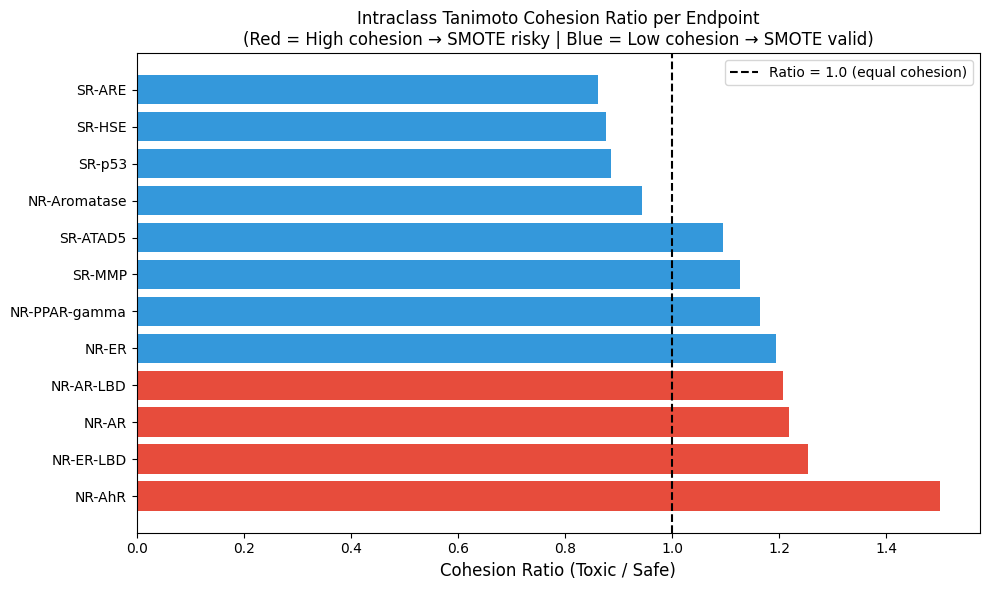

Chart saved.


In [6]:
# Visualise the cohesion table as a horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if r > 1.2 else '#3498db' for r in cohesion_df['cohesion_ratio']]
bars = ax.barh(cohesion_df['endpoint'], cohesion_df['cohesion_ratio'], color=colors)
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5, label='Ratio = 1.0 (equal cohesion)')
ax.set_xlabel('Cohesion Ratio (Toxic / Safe)', fontsize=12)
ax.set_title('Intraclass Tanimoto Cohesion Ratio per Endpoint\n(Red = High cohesion → SMOTE risky | Blue = Low cohesion → SMOTE valid)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/cohesion_ratio_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

## Step 3B: Sensitivity Analysis — Empirical SMOTE Threshold
We do NOT hardcode 1.5. We test 6 candidate thresholds and let Macro AUPRC on the validation set pick the winner.

In [7]:
print('Running SMOTE threshold sensitivity analysis...')
result = find_optimal_smote_threshold(
    cohesion_df=cohesion_df,
    X_train=X_fp_train,
    Y_train=Y_train,
    X_val=X_fp_val,
    Y_val=Y_val,
    target_cols=TARGET_COLS,
    candidate_thresholds=[1.0, 1.2, 1.5, 1.8, 2.0, 2.5]
)

OPTIMAL_THRESHOLD = result['threshold']
print(f'\nOptimal threshold locked in: {OPTIMAL_THRESHOLD}')

Running SMOTE threshold sensitivity analysis...
  Threshold 1.0: Macro AUPRC = 0.4242
  Threshold 1.2: Macro AUPRC = 0.4263
  Threshold 1.5: Macro AUPRC = 0.4365
  Threshold 1.8: Macro AUPRC = 0.4360
  Threshold 2.0: Macro AUPRC = 0.4360
  Threshold 2.5: Macro AUPRC = 0.4360

✅ Optimal cohesion threshold: 1.5 (AUPRC = 0.4365)

Optimal threshold locked in: 1.5


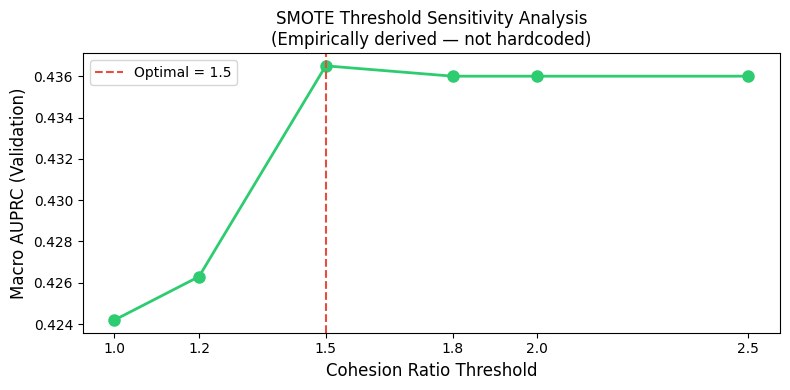

In [8]:
# Plot the sensitivity curve
thresholds = list(result['all_results'].keys())
auprcs     = list(result['all_results'].values())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, auprcs, 'o-', color='#2ecc71', linewidth=2, markersize=8)
ax.axvline(OPTIMAL_THRESHOLD, color='#e74c3c', linestyle='--', label=f'Optimal = {OPTIMAL_THRESHOLD}')
ax.set_xlabel('Cohesion Ratio Threshold', fontsize=12)
ax.set_ylabel('Macro AUPRC (Validation)', fontsize=12)
ax.set_title('SMOTE Threshold Sensitivity Analysis\n(Empirically derived — not hardcoded)', fontsize=12)
ax.legend()
ax.xaxis.set_major_locator(mticker.FixedLocator(thresholds))
plt.tight_layout()
plt.savefig('../data/processed/smote_sensitivity_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3C: Build Final SMOTE Validity Map
Using the empirically derived threshold, tag each endpoint as SMOTE-valid or not.

In [9]:
cohesion_df['smote_valid'] = cohesion_df['cohesion_ratio'] < OPTIMAL_THRESHOLD
print(f'SMOTE-valid endpoints ({(cohesion_df["smote_valid"]).sum()}/12):')
display(cohesion_df[['endpoint', 'cohesion_ratio', 'smote_valid']])

SMOTE-valid endpoints (11/12):


,endpoint,cohesion_ratio,smote_valid
2,NR-AhR,1.500,False
5,NR-ER-LBD,1.253,True
0,NR-AR,1.219,True
1,NR-AR-LBD,1.208,True
4,NR-ER,1.194,True
6,NR-PPAR-gamma,1.164,True
10,SR-MMP,1.127,True
8,SR-ATAD5,1.095,True
3,NR-Aromatase,0.944,True
11,SR-p53,0.886,True


In [10]:
import os, pickle
os.makedirs('../data/processed', exist_ok=True)

cohesion_df.to_csv('../data/processed/cohesion_table.csv', index=False)

phase3_artifacts = {
    'cohesion_df':          cohesion_df,
    'optimal_threshold':    OPTIMAL_THRESHOLD,
    'sensitivity_results':  result['all_results'],
}
with open('../data/processed/phase3_artifacts.pkl', 'wb') as f:
    pickle.dump(phase3_artifacts, f)

print('Phase 3 artifacts saved.')
print('\n Summary:')
print(f'  Optimal SMOTE threshold : {OPTIMAL_THRESHOLD}')
print(f'  SMOTE-valid endpoints   : {cohesion_df["smote_valid"].sum()} / 12')
print(f'  SMOTE-invalid endpoints : {(~cohesion_df["smote_valid"]).sum()} / 12')
print('\nPhase 3 Complete.')

Phase 3 artifacts saved.

 Summary:
  Optimal SMOTE threshold : 1.5
  SMOTE-valid endpoints   : 11 / 12
  SMOTE-invalid endpoints : 1 / 12

Phase 3 Complete.
